In [1]:
import matplotlib.pyplot as plt
import numpy as np
import soundfile as sf

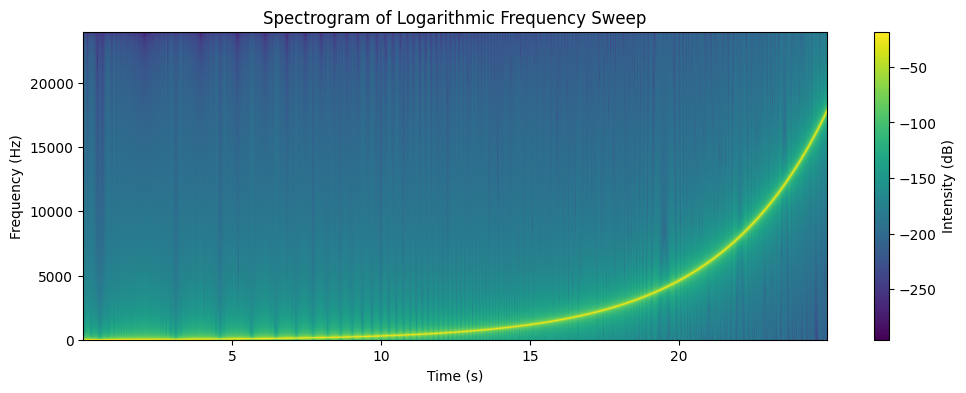

In [8]:
def log_sweep(fs, T, f1, f2):
    t = np.linspace(0, T, int(fs*T), endpoint=False)
    K = T / np.log(f2/f1)
    _sweep = np.sin(2*np.pi*f1*K*(np.exp(t/K)-1))
    _sweep /= np.max(np.abs(_sweep))
    return _sweep

fs = 48000
sweep = log_sweep(fs, 25, 20, 18000)


plt.figure(figsize=(12, 4))
plt.specgram(sweep, Fs=fs, NFFT=2048, noverlap=1024)
plt.title('Spectrogram of Logarithmic Frequency Sweep')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.colorbar(label='Intensity (dB)')
plt.show()

In [9]:
import numpy as np
import soundfile as sf

sf.write(
    "sweep.wav",
    sweep,
    samplerate=48000,
    subtype="FLOAT"
)

## List microphone inputs

```bash
arecord -l
```

```bash
arecord -D hw:0,0 -f S16_LE -c 1 -r 48000 -d 30 record.wav
```

## Play a sound

```bash
aplay -vv sweep.wav
```

Impulsion calculée et sauvegardée dans 'impulsion_test.wav'


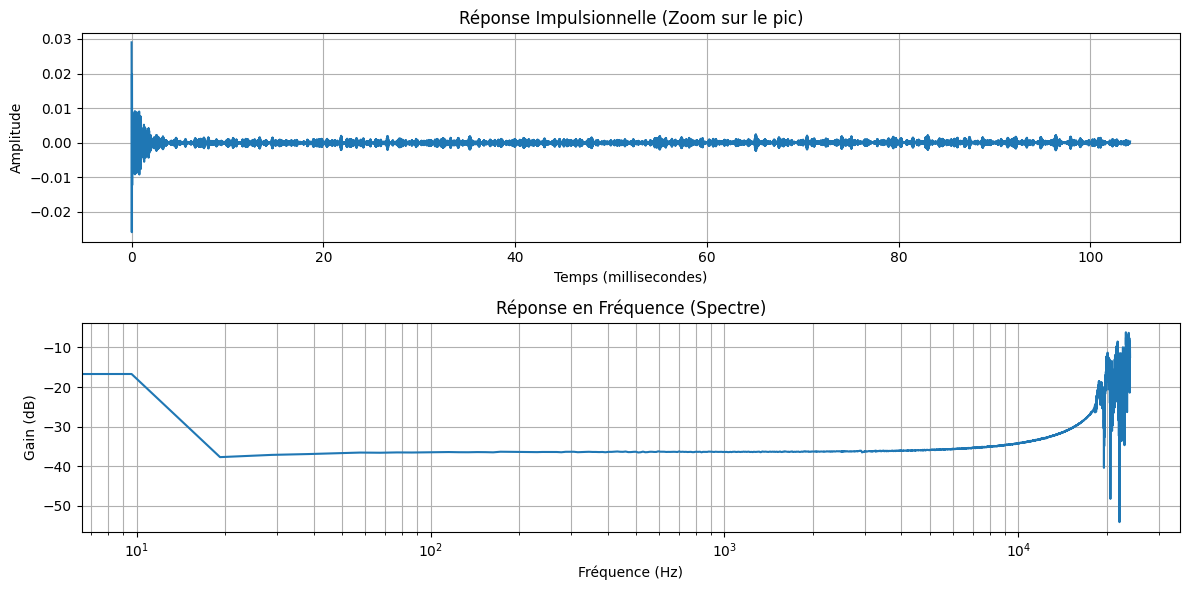

In [18]:
import numpy as np
import soundfile as sf
import matplotlib.pyplot as plt
from scipy import signal

# On garde la fonction, mais on ne l'utilise pas pour le sweep de référence directement
def load_and_prepare(filename, target_length):
    try:
        data, fs = sf.read(filename)
        if len(data.shape) > 1:
            data = np.mean(data, axis=1)
        data = data / (np.max(np.abs(data)) + 1e-9)

        # On redimensionne pour matcher la target_length
        if len(data) < target_length:
            data = np.pad(data, (0, target_length - len(data)))
        else:
            data = data[:target_length]
        return data, fs
    except FileNotFoundError:
        print(f"Erreur : Le fichier {filename} est introuvable.")
        return None, None

# --- 1. Chargement des fichiers (CORRIGÉ) ---

# A. On charge le sweep original pour connaître sa "vraie" taille
try:
    # Attention : vérifie bien le nom du fichier ici ('sweep_48k.wav' ou 'sweep.wav')
    sweep_orig, fs = sf.read('sweep.wav')

    # Passage en mono si nécessaire
    if len(sweep_orig.shape) > 1:
        sweep_orig = np.mean(sweep_orig, axis=1)

    # Normalisation
    sweep_orig = sweep_orig / (np.max(np.abs(sweep_orig)) + 1e-9)

    # B. On charge l'enregistrement et on le force à la taille du sweep original
    recording, _ = load_and_prepare('record.wav', len(sweep_orig))

    # On assigne à 'sweep' pour la suite du script
    sweep = sweep_orig

except FileNotFoundError:
    print("Vérifie que le fichier 'sweep_48k.wav' existe dans le dossier !")
    # On arrête tout si le fichier n'existe pas pour éviter l'erreur FFT
    exit()
#
if sweep is not None and recording is not None:
    # --- 2. Déconvolution (Le cœur du sujet) ---
    # On passe dans le domaine fréquentiel (FFT)
    sweep_fft = np.fft.rfft(sweep)
    rec_fft = np.fft.rfft(recording)

    # Division spectrale avec régularisation (pour éviter le bruit)
    # Le 1e-6 empêche la division par zéro
    ir_fft = rec_fft / (sweep_fft + 1e-6)

    # Retour au domaine temporel
    ir = np.fft.irfft(ir_fft)

    # --- 3. Synchronisation (Auto-Align) ---
    # Si tu as mis du temps avant de lancer aplay, l'impulsion est décalée.
    # On cherche l'indice du pic le plus fort.
    peak_index = np.argmax(np.abs(ir))

    # On coupe ce qu'il y a avant le pic (le silence) pour centrer l'impulsion
    # On garde 5000 échantillons après le pic pour voir la réponse
    ir_cropped = ir[peak_index : peak_index + 5000]
    time_axis = np.arange(len(ir_cropped)) / fs

    # --- 4. Sauvegarde ---
    sf.write('impulsion_test.wav', ir_cropped, fs)
    print("Impulsion calculée et sauvegardée dans 'impulsion_test.wav'")

    # --- 5. Visualisation ---
    plt.figure(figsize=(12, 6))
    plt.subplot(2, 1, 1)
    plt.plot(time_axis * 1000, ir_cropped)
    plt.title("Réponse Impulsionnelle (Zoom sur le pic)")
    plt.xlabel("Temps (millisecondes)")
    plt.ylabel("Amplitude")
    plt.grid(True)

    # Affichage de la réponse en fréquence (magnitude)
    plt.subplot(2, 1, 2)
    freq_response = 20 * np.log10(np.abs(np.fft.rfft(ir_cropped)) + 1e-6)
    freqs = np.fft.rfftfreq(len(ir_cropped), 1/fs)
    plt.semilogx(freqs, freq_response)
    plt.title("Réponse en Fréquence (Spectre)")
    plt.xlabel("Fréquence (Hz)")
    plt.ylabel("Gain (dB)")
    plt.grid(True, which="both", ls="-")

    plt.tight_layout()
    plt.show()
else:
    print("Vérifie que sweep.wav et test_recording.wav existent.")